Loaded with encoding=gbk

[计数检查] 原始细胞数：
M1  : 14750
CD4T: 6087
CD8T: 25799

[核对 n] 有效样本量（能找到最近 M1 的目标细胞数）：
CD4T: {'T001': 192, 'T002': 268, 'T004': 87, 'T005': 452, 'T006': 498}
CD8T: {'T001': 881, 'T002': 366, 'T004': 202, 'T005': 3536, 'T006': 1101}

Saved files:
C:/Users/Li Chujia/ipynb/typex\Fig3c_CDF_CD4_CD8_to_nearest_M1.png
C:/Users/Li Chujia/ipynb/typex\Fig3c_CDF_CD4_CD8_to_nearest_M1.pdf


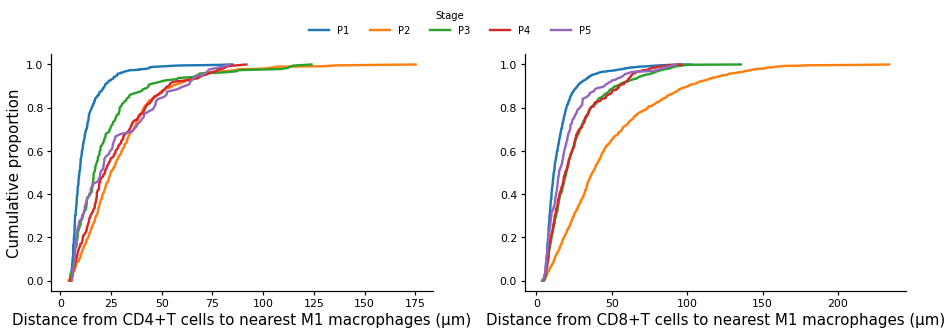


=== 统计A：CD4T→M1（阶段差异）===
Kruskal–Wallis: H=353.9315, p=2.4837e-75

MWU 两两比较（FDR）：


,T001,T002,T004,T005,T006
T001,NaN,0.0003,0.2257,0.0,0.0000
T002,0.0003,NaN,0.2881,0.0,0.0861
T004,0.2257,0.2881,NaN,0.0,0.0483
T005,0.0000,0.0000,0.0000,NaN,0.0000
T006,0.0000,0.0861,0.0483,0.0,NaN



KS 两两比较（FDR）：


,T001,T002,T004,T005,T006
T001,NaN,0.0039,0.0419,0.0,0.0000
T002,0.0039,NaN,0.1551,0.0,0.0447
T004,0.0419,0.1551,NaN,0.0,0.0113
T005,0.0000,0.0000,0.0000,NaN,0.0000
T006,0.0000,0.0447,0.0113,0.0,NaN



=== 统计A：CD8T→M1（阶段差异）===
Kruskal–Wallis: H=1415.5115, p=2.9928e-305

MWU 两两比较（FDR）：


...


=== 统计B：同一时期内 CD4T→M1 vs CD8T→M1 ===

MWU（每个时期一项）+ FDR：


,p_raw,p_fdr
T001,0.009887,0.016478
T002,0.033159,0.041449
T004,0.049960,0.049960
T005,0.000000,0.000000
T006,0.000000,0.000000



KS（每个时期一项）+ FDR：


,p_raw,p_fdr
T001,0.022368,0.028521
T002,0.071633,0.071633
T004,0.022817,0.028521
T005,0.000000,0.000000
T006,0.000000,0.000000



DONE.


In [1]:
# -*- coding: utf-8 -*-
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import kruskal, mannwhitneyu, ks_2samp
from IPython.display import display

# =========================
# 基本配置
# =========================
CSV_PATH      = r"C:\Users\Li Chujia\Desktop\cell_annotationV2\annotated_cells_mixed.csv"
COL_STAGE     = "标签"        # T001/T002/T004/T005/T006
COL_SLICE     = "子标签"      # ROIxxx
COL_CELLTYPE  = "cell_type"
COL_IL1B      = "IL_1b"
COL_TNFA      = "TNFa"
STAGES_ORDER  = ["T001", "T002", "T004", "T005", "T006"]

# =========================
# 输出保存设置
# =========================
OUT_DIR = r"C:/Users/Li Chujia/ipynb/typex"
OUT_BASENAME = "Fig3c_CDF_CD4_CD8_to_nearest_M1"

SAVE_PNG = True
SAVE_PDF = True
DPI = 600
SHOW_FIG = True

# =========================
# 图形参数（可手动调整）
# =========================
FIG_W = 13.2
FIG_H = 5.0
WSPACE = 0.24
TOP_MARGIN = 0.82
BOTTOM_MARGIN = 0.16
LEFT_MARGIN = 0.08
RIGHT_MARGIN = 0.98

X_LABEL_SIZE = 15
Y_LABEL_SIZE = 15
X_TICK_SIZE  = 11
Y_TICK_SIZE  = 11
LEGEND_SIZE  = 10

AXIS_LW = 1.2
LINE_W = 2.4

LEGEND_Y = 0.965
LEGEND_NCOL = 5

# =========================
# 图例顺序 & 显示文字
# P1–P5 映射（按你之前的定义）
# =========================
stage_to_P = {
    "T005": "P1",
    "T006": "P2",
    "T001": "P3",
    "T002": "P4",
    "T004": "P5",
}

legend_order = ["T005", "T006", "T001", "T002", "T004"]  # P1→P5
legend_label = {k: v for k, v in stage_to_P.items()}

# =========================
# 坐标列候选（自动识别）
# =========================
CAND_X_COLS = ["X", "x", "X_position", "Xpos", "XPos", "CenterX", "center_x", "X_um", "X (um)"]
CAND_Y_COLS = ["Y", "y", "Y_position", "Ypos", "YPos", "CenterY", "center_y", "Y_um", "Y (um)"]

# =========================
# 按“时期→切片白名单”过滤
# =========================
STAGE_SLICE_WHITELIST = {
    "T001": {"ROI001", "ROI003", "ROI007"},
    "T002": {"ROI023"},
    "T006": {"ROI001", "ROI003"},
    "T004": {"ROI010"},
    "T005": {"ROI001", "ROI003", "ROI004"},
}

# =========================
# 颜色（与前面风格保持一致）
# =========================
COLOR_MAP = {
    "T005": "#1f77b4",  # P1 blue
    "T006": "#ff7f0e",  # P2 orange
    "T001": "#2ca02c",  # P3 green
    "T002": "#d62728",  # P4 red
    "T004": "#9467bd",  # P5 purple
}

# =========================
# 小工具
# =========================
def find_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def normalize_celltype(x: str) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip().upper()
    cd4t_aliases = {"CD4_T","CD4 T","CD4+T","CD4T","CD4T CELL","CD4T_CELL"}
    cd8t_aliases = {"CD8_T","CD8 T","CD8+T","CD8T","CD8T CELL","CD8T_CELL"}
    m1_aliases   = {"M1","M1_MACROPHAGE","M1-LIKE","HUBM1","M1 LIKE","M1_MAC"}
    if s in cd4t_aliases:
        return "CD4T"
    if s in cd8t_aliases:
        return "CD8T"
    if s in m1_aliases:
        return "M1"
    s2 = re.sub(r"[^A-Z0-9]", "", s)
    if "CD4" in s2 and "T" in s2:
        return "CD4T"
    if "CD8" in s2 and "T" in s2:
        return "CD8T"
    if s2.startswith("M1"):
        return "M1"
    return s2

def stepwise_cdf(d):
    if len(d) == 0:
        return np.array([]), np.array([])
    d = np.sort(np.asarray(d, float))
    y = np.arange(1, len(d) + 1) / len(d)
    x = np.concatenate([[d[0]], d])
    y = np.concatenate([[0.0], y])
    return x, y

def set_jcc_style_axes(ax):
    # 仅保留左/下坐标轴
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(AXIS_LW)
    ax.spines["bottom"].set_linewidth(AXIS_LW)

    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")

    ax.tick_params(
        axis="x",
        which="both",
        direction="out",
        labelsize=X_TICK_SIZE,
        width=AXIS_LW,
        length=4
    )
    ax.tick_params(
        axis="y",
        which="both",
        direction="out",
        labelsize=Y_TICK_SIZE,
        width=AXIS_LW,
        length=4
    )

    ax.grid(False)

def save_figure(fig, out_dir, out_basename, save_png=True, save_pdf=True, dpi=600):
    os.makedirs(out_dir, exist_ok=True)
    saved_files = []

    if save_png:
        png_path = os.path.join(out_dir, f"{out_basename}.png")
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        saved_files.append(png_path)

    if save_pdf:
        pdf_path = os.path.join(out_dir, f"{out_basename}.pdf")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
        saved_files.append(pdf_path)

    return saved_files

def build_stage_to_dists(
    df, target_mask, hub_mask,
    stages=STAGES_ORDER,
    col_stage=COL_STAGE,
    col_slice=COL_SLICE,
    stage_slice_whitelist=None
):
    """
    按时期×切片计算 target → 最近 hub 的最小距离；返回 {stage: np.array}
    """
    out = {}
    stage_slice_whitelist = stage_slice_whitelist or {}

    for stg in stages:
        sub_stage = df[df[col_stage].astype(str).str.strip() == stg]
        if sub_stage.empty:
            continue

        keep_set = stage_slice_whitelist.get(stg, None)
        if keep_set is not None:
            keep_set = set(keep_set)
            sub_stage = sub_stage[sub_stage[col_slice].isin(keep_set)]

        dists_all = []
        for _, sub in sub_stage.groupby(col_slice):
            target_xy = sub.loc[target_mask.loc[sub.index], [col_x, col_y]].dropna().to_numpy()
            hub_xy    = sub.loc[hub_mask.loc[sub.index],    [col_x, col_y]].dropna().to_numpy()
            if len(target_xy) == 0 or len(hub_xy) == 0:
                continue

            d, _ = cKDTree(hub_xy).query(target_xy, k=1, workers=-1)
            if len(d) > 0:
                dists_all.append(d)

        if dists_all:
            out[stg] = np.concatenate(dists_all, axis=0)

    return out

def bh_fdr_matrix(df_p):
    flat = df_p.values.flatten()
    mask = ~np.isnan(flat)
    try:
        from statsmodels.stats.multitest import multipletests
        _, p_adj, _, _ = multipletests(flat[mask], method="fdr_bh")
    except Exception:
        p_adj = flat[mask]
    out = np.full_like(flat, np.nan, dtype=float)
    out[mask] = p_adj
    return pd.DataFrame(out.reshape(df_p.shape), index=df_p.index, columns=df_p.columns)

def bh_fdr_vector(pvals, labels):
    pvals = np.asarray(pvals, float)
    mask = ~np.isnan(pvals)
    try:
        from statsmodels.stats.multitest import multipletests
        _, p_adj, _, _ = multipletests(pvals[mask], method="fdr_bh")
    except Exception:
        p_adj = pvals[mask]
    out = np.full_like(pvals, np.nan, dtype=float)
    out[mask] = p_adj
    return pd.DataFrame({"p_raw": pvals, "p_fdr": out}, index=labels)

# =========================
# 读取与预处理
# =========================
df = None
for enc in ["utf-8", "gbk", "latin1", "gb18030", "utf-8-sig"]:
    try:
        df = pd.read_csv(CSV_PATH, encoding=enc)
        print(f"Loaded with encoding={enc}")
        break
    except Exception:
        pass
if df is None:
    raise RuntimeError(f"无法读取：{CSV_PATH}")

for c in [COL_STAGE, COL_SLICE, COL_CELLTYPE]:
    if c not in df.columns:
        raise KeyError(f"缺少列：{c}")

col_x = find_first_col(df, CAND_X_COLS)
col_y = find_first_col(df, CAND_Y_COLS)
if col_x is None or col_y is None:
    raise KeyError(f"未找到坐标列。X候选={CAND_X_COLS}；Y候选={CAND_Y_COLS}")

df[col_x] = pd.to_numeric(df[col_x], errors="coerce")
df[col_y] = pd.to_numeric(df[col_y], errors="coerce")
df = df.dropna(subset=[col_x, col_y]).copy()

df["_ct_norm"] = df[COL_CELLTYPE].astype(str).map(normalize_celltype)

# =========================
# Hub / Target
# =========================
hub_m1   = (df["_ct_norm"] == "M1")
mask_cd4 = (df["_ct_norm"] == "CD4T")
mask_cd8 = (df["_ct_norm"] == "CD8T")

print("\n[计数检查] 原始细胞数：")
print("M1  :", int(hub_m1.sum()))
print("CD4T:", int(mask_cd4.sum()))
print("CD8T:", int(mask_cd8.sum()))

# =========================
# 计算距离分布（按时期，且按白名单过滤切片）
# =========================
stage_to_dists_cd4 = build_stage_to_dists(
    df, mask_cd4, hub_m1,
    stage_slice_whitelist=STAGE_SLICE_WHITELIST
)
stage_to_dists_cd8 = build_stage_to_dists(
    df, mask_cd8, hub_m1,
    stage_slice_whitelist=STAGE_SLICE_WHITELIST
)

print("\n[核对 n] 有效样本量（能找到最近 M1 的目标细胞数）：")
print("CD4T:", {s: len(stage_to_dists_cd4[s]) for s in stage_to_dists_cd4})
print("CD8T:", {s: len(stage_to_dists_cd8[s]) for s in stage_to_dists_cd8})

# =========================
# 作图：仅保留两个原始大小图，横向排列
# 不要上方标题；横坐标中体现 CD4/CD8
# =========================
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), sharey=True)

# ---- 左图：CD4 ----
ax = axes[0]
handles = []
labels = []

for stg in [s for s in legend_order if s in stage_to_dists_cd4]:
    xs, ys = stepwise_cdf(stage_to_dists_cd4[stg])
    line, = ax.plot(
        xs, ys,
        color=COLOR_MAP[stg],
        linewidth=LINE_W,
        label=legend_label.get(stg, stg)
    )
    handles.append(line)
    labels.append(legend_label.get(stg, stg))

ax.set_xlabel("Distance from CD4+T cells to nearest M1 macrophages (μm)", fontsize=X_LABEL_SIZE)
ax.set_ylabel("Cumulative proportion", fontsize=Y_LABEL_SIZE)
set_jcc_style_axes(ax)

# ---- 右图：CD8 ----
ax = axes[1]
for stg in [s for s in legend_order if s in stage_to_dists_cd8]:
    xs, ys = stepwise_cdf(stage_to_dists_cd8[stg])
    ax.plot(
        xs, ys,
        color=COLOR_MAP[stg],
        linewidth=LINE_W,
        label=legend_label.get(stg, stg)
    )

ax.set_xlabel("Distance from CD8+T cells to nearest M1 macrophages (μm)", fontsize=X_LABEL_SIZE)
set_jcc_style_axes(ax)

# 整张图共用顶部图例
fig.legend(
    handles, labels,
    title="Stage",
    frameon=False,
    fontsize=LEGEND_SIZE,
    title_fontsize=LEGEND_SIZE,
    loc="upper center",
    bbox_to_anchor=(0.5, LEGEND_Y),
    ncol=LEGEND_NCOL
)

plt.subplots_adjust(
    left=LEFT_MARGIN,
    right=RIGHT_MARGIN,
    bottom=BOTTOM_MARGIN,
    top=TOP_MARGIN,
    wspace=WSPACE
)

saved_files = save_figure(
    fig,
    out_dir=OUT_DIR,
    out_basename=OUT_BASENAME,
    save_png=SAVE_PNG,
    save_pdf=SAVE_PDF,
    dpi=DPI
)

print("\nSaved files:")
for f in saved_files:
    print(f)

if SHOW_FIG:
    plt.show()
else:
    plt.close(fig)

# =========================
# 统计A：不同阶段是否不同（KW + 两两FDR）
# =========================
def stage_group_tests(stage_to_dists, name):
    labels = [s for s in STAGES_ORDER if s in stage_to_dists]
    groups = [stage_to_dists[s] for s in labels]
    print(f"\n=== 统计A：{name}（阶段差异）===")
    if len(groups) < 2:
        print("组数不足，跳过。")
        return
    H, p_kw = kruskal(*groups)
    print(f"Kruskal–Wallis: H={H:.4f}, p={p_kw:.4e}")

    import itertools
    pairs = list(itertools.combinations(labels, 2))
    mwu_p = pd.DataFrame(np.nan, index=labels, columns=labels)
    ks_p  = pd.DataFrame(np.nan, index=labels, columns=labels)

    for a, b in pairs:
        da, db = stage_to_dists[a], stage_to_dists[b]
        try:
            mwu_p.loc[a, b] = mwu_p.loc[b, a] = mannwhitneyu(da, db, alternative="two-sided").pvalue
        except Exception:
            pass
        try:
            ks_p.loc[a, b] = ks_p.loc[b, a] = ks_2samp(da, db, alternative="two-sided").pvalue
        except Exception:
            pass

    print("\nMWU 两两比较（FDR）：")
    display(bh_fdr_matrix(mwu_p).round(4))
    print("\nKS 两两比较（FDR）：")
    display(bh_fdr_matrix(ks_p).round(4))

stage_group_tests(stage_to_dists_cd4, "CD4T→M1")
stage_group_tests(stage_to_dists_cd8, "CD8T→M1")

# =========================
# 统计B：同一时期内 CD4T vs CD8T（FDR）
# =========================
print("\n=== 统计B：同一时期内 CD4T→M1 vs CD8T→M1 ===")

stage_labels_list = []
p_mwu_list = []
p_ks_list  = []

for stg in STAGES_ORDER:
    d4 = stage_to_dists_cd4.get(stg, np.array([]))
    d8 = stage_to_dists_cd8.get(stg, np.array([]))
    stage_labels_list.append(stg)

    if len(d4) == 0 or len(d8) == 0:
        p_mwu_list.append(np.nan)
        p_ks_list.append(np.nan)
        continue

    p_mwu_list.append(mannwhitneyu(d4, d8, alternative="two-sided").pvalue)
    p_ks_list.append(ks_2samp(d4, d8, alternative="two-sided").pvalue)

print("\nMWU（每个时期一项）+ FDR：")
display(bh_fdr_vector(p_mwu_list, stage_labels_list).round(6))

print("\nKS（每个时期一项）+ FDR：")
display(bh_fdr_vector(p_ks_list, stage_labels_list).round(6))

print("\nDONE.")